In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator
import ternary
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
from matplotlib.lines import Line2D

In [2]:
MARG = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'MARG')
VAN = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'VAN')
WILSON = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'WILSON')

In [3]:
datasets = [
    (WILSON, 'Ternary Diagram - Wilson Method'),
    (VAN, 'Ternary Diagram - Van Laar Method'),
    (MARG, 'Ternary Diagram - Margules Method')
]

In [4]:
def plot_ternary(df, ax, title, scale=100):
    df_copy = df.copy()

    # Normalize fractions
    total = df_copy[['x1', 'x2', 'x3']].sum(axis=1)
    df_copy[['x1', 'x2', 'x3']] = df_copy[['x1', 'x2', 'x3']].div(total, axis=0)

    # Interpolation
    points = df_copy[['x1', 'x2']].values
    values = df_copy['P (bar)'].values
    interp = LinearNDInterpolator(points, values)

    # Grid
    heatmap_data = {}
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            x1, x2 = i / scale, j / scale
            p_val = interp([[x1, x2]])[0]
            if np.isfinite(p_val):
                heatmap_data[(i, j, k)] = float(p_val)

    if not heatmap_data:
        raise ValueError(f"Interpolation yielded no finite values for: {title}")
    vmin = min(heatmap_data.values())
    vmax = max(heatmap_data.values())

    # Ternary subplots
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)
    ax.axis("off")

    # Heatmap
    tax.heatmap(
        heatmap_data,
        style="triangular",
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        colorbar=False
    )

    # Resyncing the color bar just to add a label
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pressure (bar)", size = 14)
    
    # Styling
    tax.boundary(linewidth=1.2)
    tax.gridlines(multiple=10, color="gray", linewidth=0.4, alpha=0.5)
    tax.ticks(axis='lbr', multiple=10, linewidth=0.8, tick_formats="%.0f", offset=0.02)
    
    # Labels
    tax.set_title(title, pad=20, size = 16)
    tax.left_axis_label("Ethyl Acetate (mol %)", offset=0.14, size = 14)
    tax.right_axis_label("Ethanol (mol %)", offset=0.14, size = 14)
    tax.bottom_axis_label("Methyl Acetate (mol %)", offset=0.08, size = 14)

    # Prevent double ticks
    tax.clear_matplotlib_ticks()
   
    tax._redraw_labels()

In [5]:
def plot_k_lines(df, ax, title, scale=100):
    df_copy = df.copy()

    # Normalize fractions
    total = df_copy[['x1', 'x2', 'x3']].sum(axis=1)
    df_copy[['x1', 'x2', 'x3']] = df_copy[['x1', 'x2', 'x3']].div(total, axis=0)

    # Initialize ternary subplot
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)
    ax.axis("off")

    # Project points to 2D cartesian 
    coords = df_copy[['x1', 'x2', 'x3']].values * scale
    cartesian_points = [ternary.helpers.project_point(row) for row in coords]
    x_cart = np.array([p[0] for p in cartesian_points])
    y_cart = np.array([p[1] for p in cartesian_points])

    # plot K1
    k1_vals = np.array(df_copy['K1'].values, dtype=float)
    mask1 = np.isfinite(k1_vals)
    if len(k1_vals[mask1]) > 3:
        ax.tricontour(x_cart[mask1], y_cart[mask1], k1_vals[mask1], levels=[1.0], colors='red', linewidths=2)

    # plot K2
    k2_vals = np.array(df_copy['K2'].values, dtype=float)
    mask2 = np.isfinite(k2_vals)
    if len(k2_vals[mask2]) > 3:
        ax.tricontour(x_cart[mask2], y_cart[mask2], k2_vals[mask2], levels=[1.0], colors='blue', linewidths=2, linestyles='--')

    # plot K3
    k3_vals = np.array(df_copy['K3'].values, dtype=float)
    mask3 = np.isfinite(k3_vals)
    if len(k3_vals[mask3]) > 3:
        ax.tricontour(x_cart[mask3], y_cart[mask3], k3_vals[mask3], levels=[1.0], colors='green', linewidths=2, linestyles=':')

    # Custom Legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='K1 = 1'),
        Line2D([0], [0], color='blue', lw=2, linestyle='--', label='K2 = 1'),
        Line2D([0], [0], color='green', lw=2, linestyle=':', label='K3 = 1')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Styling
    tax.boundary(linewidth=1.2)
    tax.gridlines(multiple=10, color="gray", linewidth=0.4, alpha=0.5)
    tax.ticks(axis='lbr', multiple=10, linewidth=0.8, tick_formats="%.0f", offset=0.02)
    
    # Labels
    tax.set_title(title, pad=20, size = 16)
    tax.left_axis_label("Ethyl Acetate (mol %)", offset=0.14, size = 14)
    tax.right_axis_label("Ethanol (mol %)", offset=0.14, size = 14)
    tax.bottom_axis_label("Methyl Acetate (mol %)", offset=0.08, size = 14)

    tax.clear_matplotlib_ticks()
    tax._redraw_labels()

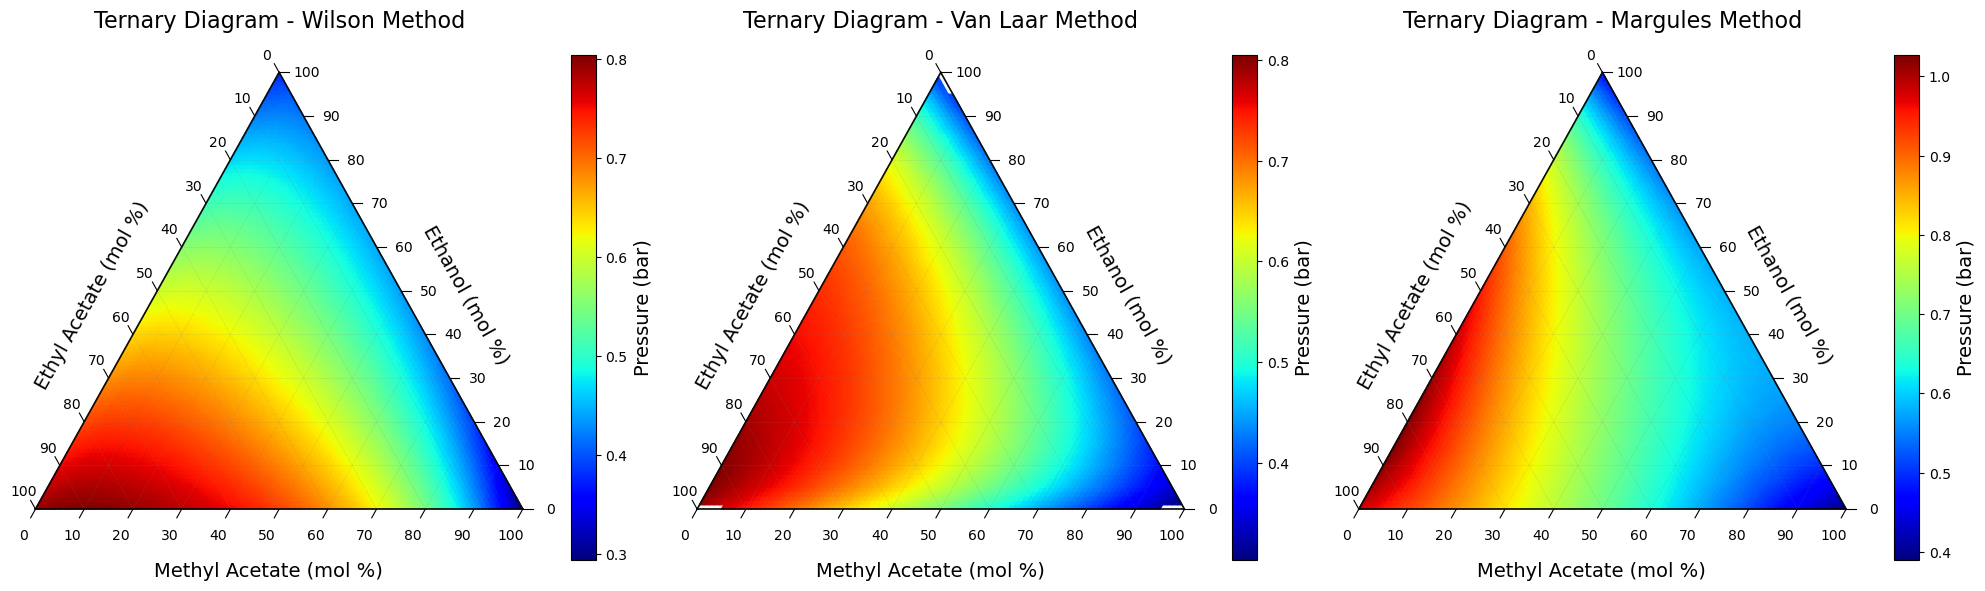

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for (data, title), ax in zip(datasets, axes):
    plot_ternary(data, ax, title)

plt.tight_layout()
plt.savefig("ternary.pdf")
plt.show()

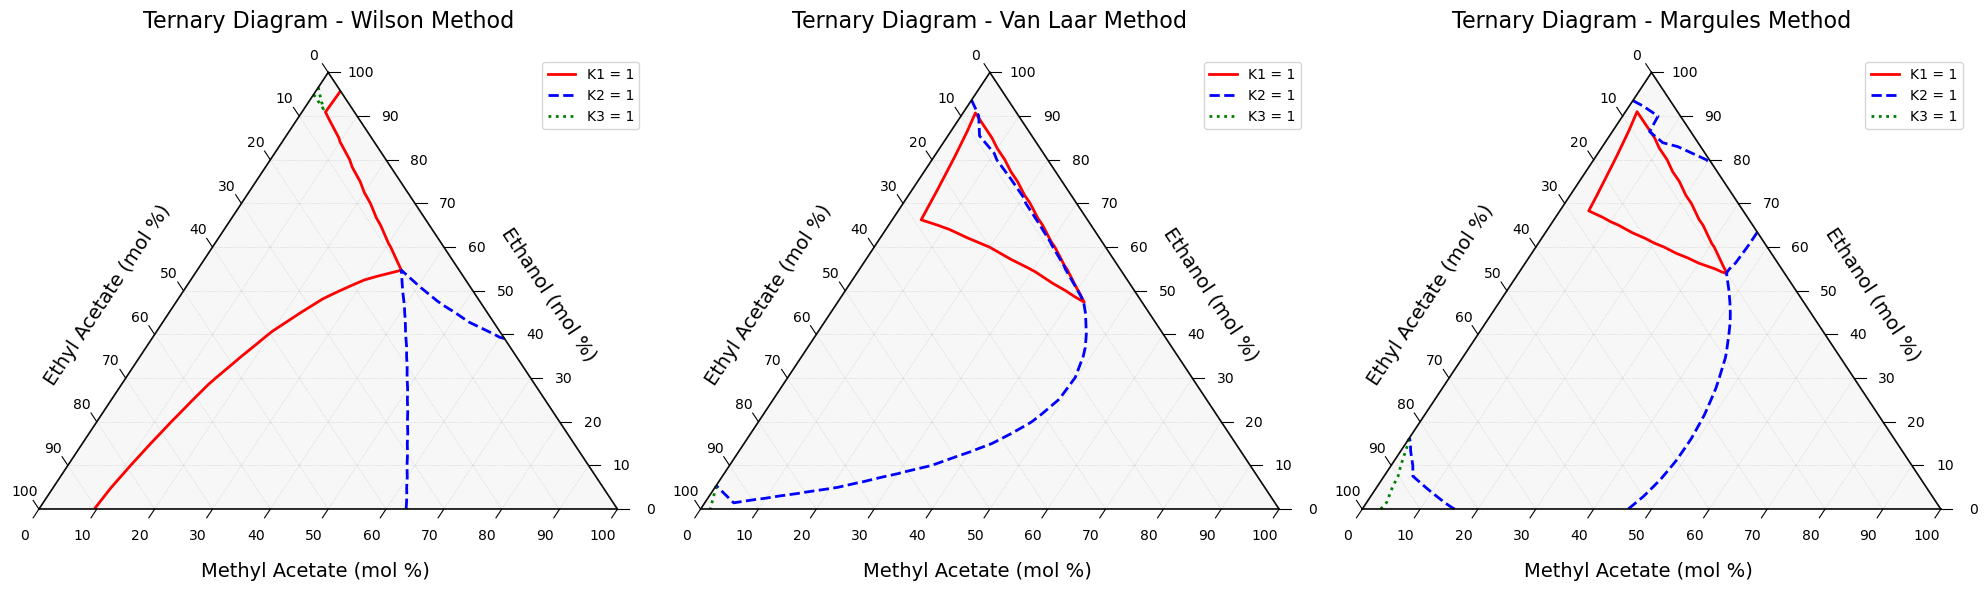

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for (data, title), ax in zip(datasets, axes):
    plot_k_lines(data, ax, title)

plt.savefig("ternary_k.pdf")
plt.tight_layout()
plt.show()